# Chargement des données

### Imports

In [640]:
import sys

from matplotlib import pyplot as plt

#sys.path.append("../src")
sys.path.insert(0, str(ROOT / "src"))

from clean_carburants import (load_raw,clean,validate, save_processed)
from fetch_carburants import fetch_raw

### Chemins

In [641]:
RAW = Path("../data/raw/prix-des-carburants-en-france-flux-instantane-v2.csv")
dest = Path("../data/processed/carburants_clean.csv")

### Chargement et Prévisualisation

In [642]:
df=load_raw(RAW)
df.head()

,id,Code postal,pop,Adresse,Ville,geom,Prix Gazole mis à jour le,Prix Gazole,Prix SP95 mis à jour le,Prix SP95,...,Prix GPLc mis à jour le,Prix GPLc,Prix E10 mis à jour le,Prix E10,Prix SP98 mis à jour le,Prix SP98,Automate 24-24 (oui/non),Département,code_departement,Région
0,89100001,89100,R,84 ROUTE DE MAILLOT,Sens,"48.183, 3.309",2026-09-28T13:45:27+02:00,2.429,NaN,NaN,...,NaN,NaN,2026-09-28T13:45:27+02:00,2.209,2026-09-28T13:42:00+02:00,2.289,Non,Yonne,89,Bourgogne-Franche-Comté
1,25115001,25115,R,Z.A. les Salines,Pouilley-les-Vignes,"47.257413021458, 5.9240872885659",2026-09-29T13:52:16+02:00,2.399,2026-09-18T12:15:51+02:00,2.239,...,2026-09-08T13:55:35+02:00,1.099,NaN,NaN,2026-09-18T12:15:52+02:00,2.289,Oui,Doubs,25,Bourgogne-Franche-Comté
2,80570001,80570,R,Rue Joliot Curie,Dargnies,"50.04475, 1.52562",2026-09-18T08:30:48+02:00,2.419,2026-09-25T08:48:02+02:00,2.249,...,NaN,NaN,NaN,NaN,2026-09-25T08:48:02+02:00,2.309,Non,Somme,80,Hauts-de-France
3,58240003,58240,R,ROUTE NATIONALE 7 - LES BOULAISES,Chantenay-Saint-Imbert,"46.7535171497, 3.1406912128899998",NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,Non,Nièvre,58,Bourgogne-Franche-Comté
4,38230003,38230,R,Rue des Ardennes,Tignieu-Jameyzieu,"45.745, 5.183",2026-10-02T11:26:00+02:00,2.356,2026-10-02T11:26:00+02:00,2.237,...,2026-10-02T11:26:00+02:00,0.998,2026-10-02T11:26:00+02:00,2.186,2026-10-02T11:26:00+02:00,2.273,Oui,Isère,38,Auvergne-Rhône-Alpes


# EXPLORATION (Profilage)

### dimensions

In [643]:
# check the shape of the DataFrame to understand how many rows and columns it contains
df.shape

(9820, 22)

### types

In [644]:
# inspect the data types of each column in the DataFrame. 
# Code postal and id are explicitly set to string types to preserve leading zeros and ensure they are treated as categorical identifiers rather than numerical values.
df.dtypes

id                               str
Code postal                      str
pop                              str
Adresse                          str
Ville                            str
geom                             str
Prix Gazole mis à jour le        str
Prix Gazole                  float64
Prix SP95 mis à jour le          str
Prix SP95                    float64
Prix E85 mis à jour le           str
Prix E85                     float64
Prix GPLc mis à jour le          str
Prix GPLc                    float64
Prix E10 mis à jour le           str
Prix E10                     float64
Prix SP98 mis à jour le          str
Prix SP98                    float64
Automate 24-24 (oui/non)         str
Département                      str
code_departement                 str
Région                           str
dtype: object

### Valeurs manquantes

In [645]:
# Number of missing values in each column
df.isna().sum()


id                              0
Code postal                     0
pop                             0
Adresse                         0
Ville                           5
geom                            0
Prix Gazole mis à jour le     849
Prix Gazole                   849
Prix SP95 mis à jour le      7056
Prix SP95                    7056
Prix E85 mis à jour le       6118
Prix E85                     6118
Prix GPLc mis à jour le      8313
Prix GPLc                    8313
Prix E10 mis à jour le       2772
Prix E10                     2772
Prix SP98 mis à jour le      2824
Prix SP98                    2824
Automate 24-24 (oui/non)        0
Département                     5
code_departement                5
Région                          5
dtype: int64

In [646]:
# check for duplicates in the 'id' column to ensure that each entry is unique. This is important for data integrity, as duplicate IDs could indicate repeated entries or errors in data collection.
df.duplicated(subset=['id']).sum()

np.int64(0)

### Statistiques

In [647]:
# min/max/mean/median/std of each column for abberrant values detection
df.describe()

,Prix Gazole,Prix SP95,Prix E85,Prix GPLc,Prix E10,Prix SP98
count,8971.000000,2764.000000,3702.000000,1507.000000,7048.000000,6996.000000
mean,2.379991,2.220506,0.902313,1.053709,2.165687,2.273401
std,0.088933,0.095149,0.073118,0.089625,0.099766,0.121267
min,2.090000,1.549000,0.777000,0.825000,1.880000,1.980000
25%,2.337000,2.199000,0.869000,0.999000,2.136000,2.248000
50%,2.382000,2.230000,0.875000,1.040000,2.173500,2.285000
75%,2.427000,2.270000,0.909000,1.096000,2.210000,2.329000
max,2.900000,2.740000,2.249000,2.310000,2.689000,2.880000


# Assemblage du pipeline (Application des fonctions)

In [648]:
df = clean(df)
df.head()

,id,adresse,code_postal,ville,departement,code_departement,region,pop,latitude,longitude,geom,automate_24_24_oui_non,carburant,prix,maj
0,89100001,84 ROUTE DE MAILLOT,89100,Sens,Yonne,89,Bourgogne-Franche-Comté,R,48.183000,3.309000,"48.183, 3.309",Non,gazole,2.429,2026-09-28 11:45:27+00:00
1,25115001,Z.A. les Salines,25115,Pouilley-les-Vignes,Doubs,25,Bourgogne-Franche-Comté,R,47.257413,5.924087,"47.257413021458, 5.9240872885659",Oui,gazole,2.399,2026-09-29 11:52:16+00:00
2,80570001,Rue Joliot Curie,80570,Dargnies,Somme,80,Hauts-de-France,R,50.044750,1.525620,"50.04475, 1.52562",Non,gazole,2.419,2026-09-18 06:30:48+00:00
4,38230003,Rue des Ardennes,38230,Tignieu-Jameyzieu,Isère,38,Auvergne-Rhône-Alpes,R,45.745000,5.183000,"45.745, 5.183",Oui,gazole,2.356,2026-10-02 09:26:00+00:00
5,5100009,RN 94,05100,Montgenèvre,Hautes-Alpes,05,Provence-Alpes-Côte d'Azur,R,44.934000,6.733000,"44.934, 6.733",Oui,gazole,2.399,2026-10-01 05:24:59+00:00



### Validating the Cleaned Data

In [649]:
# Validate the cleaned DataFrame to ensure data integrity and correctness. 
# if any of the assertions fail, an AssertionError will be raised with a descriptive message indicating the nature of the validation failure.
checked_df = validate(df)

In [650]:
# show the rows where the latitude is between 41 and 52, which corresponds to the geographical bounds of metropolitan France.
df.loc[df["latitude"].between(41, 52),["id", "latitude"]]

,id,latitude
0,89100001,48.183000
1,25115001,47.257413
2,80570001,50.044750
4,38230003,45.745000
5,5100009,44.934000
...,...,...
58881,8000010,49.741000
58885,77260013,48.970497
58887,41000001,47.624000
58888,72400018,48.124971


# ANALYSE

### Villes les plus représentées

In [651]:
# Most common cities in the dataset
# checking for duplicates in the 'Ville' column to understand the distribution of data across different cities. This can help identify if certain cities are overrepresented in the dataset, which may influence analysis results.
df['ville'].value_counts().head(10)

ville
Marseille      205
Paris          121
Nice            82
Toulouse        82
Limoges         76
Lyon            62
Montpellier     60
Nîmes           58
Annecy          49
Nantes          49
Name: count, dtype: int64

Quels carburants sont les plus présents dans les stations ?

In [652]:
df["carburant"].value_counts()

carburant
gazole    8971
e10       7048
sp98      6996
e85       3702
sp95      2764
gplc      1507
Name: count, dtype: int64

Quels carburants sont les plus présents dans les stations du='une ville donnée ? Cas de Paris.

In [653]:
df[df['ville'] == "Paris"]["carburant"].value_counts()

carburant
gazole    39
e10       33
sp98      31
e85       11
sp95       4
gplc       3
Name: count, dtype: int64

In [654]:
df.groupby("carburant")["prix"].agg(moyenne="mean", mediane="median", ecart_type="std", minimum="min", maximum="max")

,moyenne,mediane,ecart_type,minimum,maximum
carburant,,,,,
e10,2.165687,2.1735,0.099766,1.880,2.689
e85,0.902313,0.8750,0.073118,0.777,2.249
gazole,2.379991,2.3820,0.088933,2.090,2.900
gplc,1.053709,1.0400,0.089625,0.825,2.310
sp95,2.220506,2.2300,0.095149,1.549,2.740
sp98,2.273401,2.2850,0.121267,1.980,2.880


la médiane est différente de la moyenne, cela peut être dû à une distribution asymétrique ou alors la présence des valeurs extrêmes.
Visualisons la distribution :

### Distribution des prix

<Axes: >

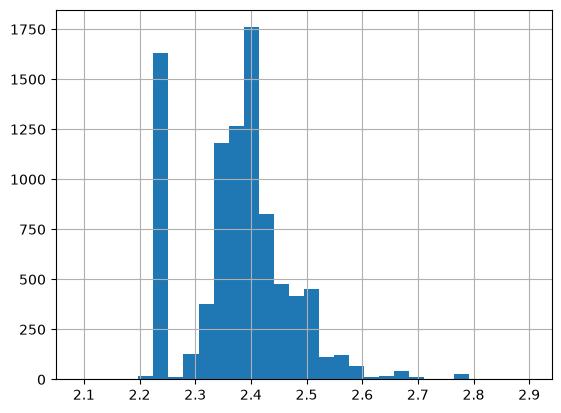

In [655]:
df[df["carburant"] == "gazole"]["prix"].hist(bins=30)

# Exporting Data for BigQuery

In [656]:
try:
    chemin = save_processed(df)
    print(f"Fichier enregistré avec succès : {dest.resolve()}")

except Exception as e:
    print(f"Erreur lors de l'enregistrement : {e}")

Fichier enregistré avec succès : C:\Users\User\OneDrive\Documents\DATA SCIENCE\Data analysis\data\processed\carburants_clean.csv
